Epoch 1, Loss: 14.6520
Epoch 11, Loss: 14.0136
Epoch 21, Loss: 13.4463
Epoch 31, Loss: 12.7812
Epoch 41, Loss: 343.2657
Epoch 51, Loss: 293.8641
Epoch 61, Loss: 253.4272
Epoch 71, Loss: 227.4388
Epoch 81, Loss: 194.8235
Epoch 91, Loss: 167.1678


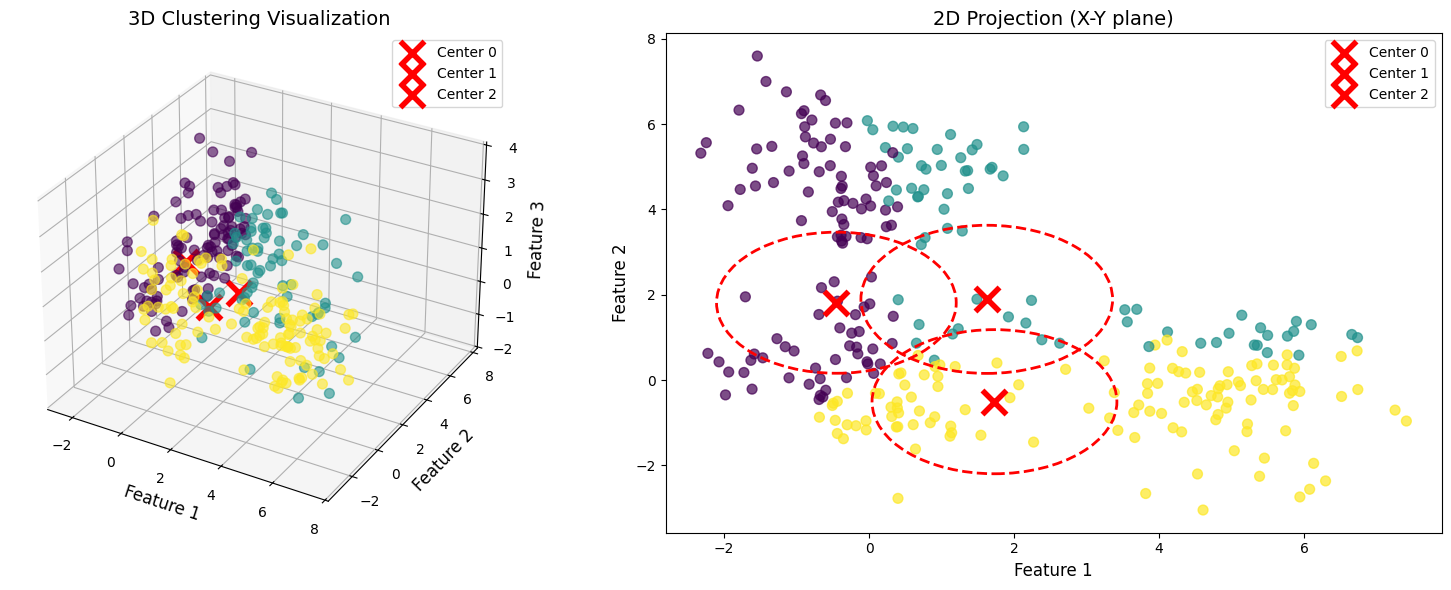


Learned sigmas: [1.6533518 1.7359936 1.6889728]
Cluster sizes: [np.int64(106), np.int64(69), np.int64(125)]


In [38]:
import numpy as np
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)
n_samples = 100
centers = np.array([[0, 0, 1], [5, 0, 1], [0, 5, 1]])
X = []
for c in centers:
    X.append(c + np.random.randn(n_samples, 3))
X = np.vstack(X)
x_torch = torch.tensor(X, dtype=torch.float32)

class RBFLayer(nn.Module):
    def __init__(self, in_features, num_rbfs):
        super(RBFLayer, self).__init__()
        self.centers = nn.Parameter(torch.rand(num_rbfs, in_features))
        self.sigma = nn.Parameter(torch.ones(num_rbfs))
        

    def forward(self, x):
       x_expanded = x.unsqueeze(1)
       c_expanded = self.centers.unsqueeze(0)
       dist_sq = torch.sum((x_expanded - c_expanded) ** 2, dim=2)
       phi = torch.exp(-dist_sq / (2 * self.sigma ** 2))
       probs = torch.softmax(phi, dim=1)
       return probs, phi 

def clustering_loss(x, probs, centers, sigmas, epoch):
    labels = torch.argmax(probs, dim=1)
    loss = 0 
    sigma_loss = 0 
    for k in range(centers.size(0)):
        mask = (labels == k)
        loss += ((x[mask] - centers[k]) ** 2).sum()
        if(epoch > 30):
            cluster_var = torch.mean(torch.sum((x[mask] - centers[k]) ** 2, dim=1))
            sigma_loss += (sigmas[k]**2 - cluster_var).pow(2)
        
    return loss/ len(x) + sigma_loss

num_clusters = 3
model = RBFLayer(in_features=3, num_rbfs=num_clusters)
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    probs, phi = model(x_torch)
    loss = clustering_loss(x_torch, probs, model.centers, model.sigma, epoch)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

with torch.no_grad():
    probs, _ = model(x_torch)
    labels = torch.argmax(probs, dim=1).numpy()
    centers_learned = model.centers.detach().numpy()
    sigma = model.sigma.detach().numpy()

# Visualization 3D
fig = plt.figure(figsize=(16, 6))

# Plot 3D
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', alpha=0.6, s=50)
for i in range(num_clusters):
    ax1.scatter(centers_learned[i, 0], centers_learned[i, 1], centers_learned[i, 2], 
                marker="x", s=300, linewidths=4, color='red', label=f"Center {i}")
ax1.set_xlabel('Feature 1', fontsize=12)
ax1.set_ylabel('Feature 2', fontsize=12)
ax1.set_zlabel('Feature 3', fontsize=12)
ax1.set_title('3D Clustering Visualization', fontsize=14)
ax1.legend()

# Plot 2D projection (X-Y)
ax2 = fig.add_subplot(122)
ax2.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, s=50)
for i in range(num_clusters):
    ax2.scatter(centers_learned[i, 0], centers_learned[i, 1], 
                marker="x", s=300, linewidths=4, color='red', label=f"Center {i}")
    circle = plt.Circle((centers_learned[i, 0], centers_learned[i, 1]), 
                        sigma[i], fill=False, linestyle='--', color='red', linewidth=2)
    ax2.add_artist(circle)
ax2.set_xlabel('Feature 1', fontsize=12)
ax2.set_ylabel('Feature 2', fontsize=12)
ax2.set_title('2D Projection (X-Y plane)', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nLearned sigmas: {sigma}")
print(f"Cluster sizes: {[np.sum(labels == i) for i in range(num_clusters)]}")